# EDA da Estação Tijuca

Este notebook será usado para a análise exploratória individual da **Estação Tijuca**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da estação é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da estação de Tijuca. Como o nome da estação pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_tijuca = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO TIJUCA"].copy()

print("Dimensoes da base da Estacao Tijuca:", df_tijuca.shape)
display(df_tijuca.head())

Dimensoes da base da Estacao Tijuca: (61368, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
4,2012-01-01 00:30:00,ESTAÇÃO TIJUCA,0.0,21.47,98.40,1.51,NaN,0.06,NaN,NaN,24.55,36.0,NaN,-22.924915,-43.232657
14,2012-01-01 01:30:00,ESTAÇÃO TIJUCA,0.2,21.36,98.41,1.89,NaN,0.08,NaN,NaN,19.00,40.0,NaN,-22.924915,-43.232657
26,2012-01-01 02:30:00,ESTAÇÃO TIJUCA,0.0,21.20,98.41,1.70,NaN,0.07,NaN,NaN,18.05,29.0,NaN,-22.924915,-43.232657
32,2012-01-01 03:30:00,ESTAÇÃO TIJUCA,0.0,21.18,98.41,1.55,NaN,0.12,NaN,NaN,12.25,12.0,NaN,-22.924915,-43.232657
36,2012-01-01 04:30:00,ESTAÇÃO TIJUCA,0.2,21.16,98.40,1.50,NaN,0.05,NaN,NaN,13.14,24.0,NaN,-22.924915,-43.232657


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [3]:
df_tijuca["data"] = pd.to_datetime(df_tijuca["data"], errors="coerce")

timestamps_unicos = df_tijuca["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_tijuca),
            df_tijuca["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2012-01-01 00:30:00
1,ultima_medicao,2018-12-31 23:30:00
2,n_linhas,61368
3,anos_cobertos,7


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a estação tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [4]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 61368
Quantidade de timestamps observados: 61368
Quantidade de timestamps faltantes: 0
Nao foram encontrados timestamps faltantes na serie.


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012,8784,8784,0,100.0
1,2013,8760,8760,0,100.0
2,2014,8760,8760,0,100.0
3,2015,8760,8760,0,100.0
4,2016,8784,8784,0,100.0
5,2017,8760,8760,0,100.0
6,2018,8760,8760,0,100.0


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2012-01,2012,1,744,744,0,100.0
1,2012-02,2012,2,696,696,0,100.0
2,2012-03,2012,3,744,744,0,100.0
3,2012-04,2012,4,720,720,0,100.0
4,2012-05,2012,5,744,744,0,100.0
5,2012-06,2012,6,720,720,0,100.0
6,2012-07,2012,7,744,744,0,100.0
7,2012-08,2012,8,744,744,0,100.0
8,2012-09,2012,9,720,720,0,100.0
9,2012-10,2012,10,744,744,0,100.0


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [5]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_tijuca.columns,
        "n_missing": df_tijuca.isna().sum().values,
        "missing_pct": (100 * df_tijuca.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 1


,coluna,n_missing,missing_pct
0,pm2_5,61368,100.0


,coluna,n_missing,missing_pct
0,pm2_5,61368,100.00
1,no,17948,29.25
2,no2,17940,29.23
3,nox,17937,29.23
4,so2,7985,13.01
5,o3,4169,6.79
6,co,3312,5.40
7,pm10,2966,4.83
8,temp,1996,3.25
9,ur,1759,2.87


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da estação.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [6]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_tijuca.columns]

df_tijuca_carac = df_tijuca.copy()
df_tijuca_carac["data"] = pd.to_datetime(df_tijuca_carac["data"], errors="coerce")
df_tijuca_carac["data_dia"] = df_tijuca_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_tijuca_carac[coluna] = pd.to_numeric(df_tijuca_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [7]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_tijuca_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,59863,1505,2.45,0.08,0.00,0.77,0.00,0.00,0.00,48.40,23.09
1,temp,meteorologica,59372,1996,3.25,24.45,23.45,5.64,20.31,27.56,11.32,46.17,0.81
2,ur,meteorologica,59609,1759,2.87,65.92,67.72,18.97,53.02,80.35,10.33,98.98,-0.36
3,co,poluente,58056,3312,5.40,0.45,0.42,0.26,0.29,0.56,0.00,12.08,5.65
4,no,poluente,43420,17948,29.25,15.37,10.15,17.67,4.25,19.84,0.00,253.92,3.27
5,no2,poluente,43428,17940,29.23,42.41,38.57,24.80,23.69,56.01,0.00,235.93,1.17
6,nox,poluente,43431,17937,29.23,57.73,50.82,36.97,31.52,75.02,0.00,418.47,1.59
7,o3,poluente,57199,4169,6.79,28.04,22.43,24.81,9.62,38.87,0.00,257.44,1.71
8,pm10,poluente,58402,2966,4.83,33.26,29.00,19.21,21.00,41.00,0.00,310.00,1.99
9,pm2_5,poluente,0,61368,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [8]:
timestamps_carac = df_tijuca_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_tijuca_carac["data_dia"].min(), df_tijuca_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_tijuca_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_ate_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_5_ou_mais_faltantes": int((faltantes_por_dia >= 5).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_ate_4_faltantes,dias_com_5_ou_mais_faltantes
0,chuva,meteorologica,24,2557,2432,50,1.96,75
1,temp,meteorologica,24,2557,2369,74,2.89,114
2,ur,meteorologica,24,2557,2381,74,2.89,102
3,co,poluente,24,2557,2178,205,8.02,174
4,no,poluente,24,2557,1229,498,19.48,830
5,no2,poluente,24,2557,1229,499,19.52,829
6,nox,poluente,24,2557,1231,497,19.44,829
7,o3,poluente,24,2557,2089,240,9.39,228
8,pm10,poluente,24,2557,2217,176,6.88,164
9,pm2_5,poluente,24,2557,0,0,0.00,2557


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


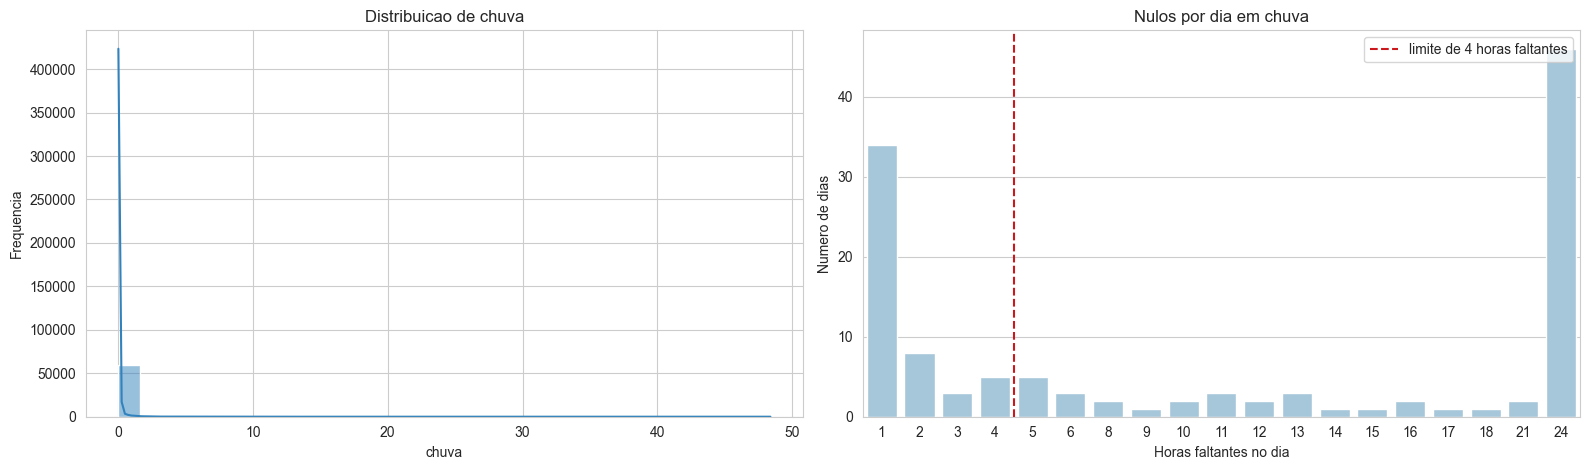

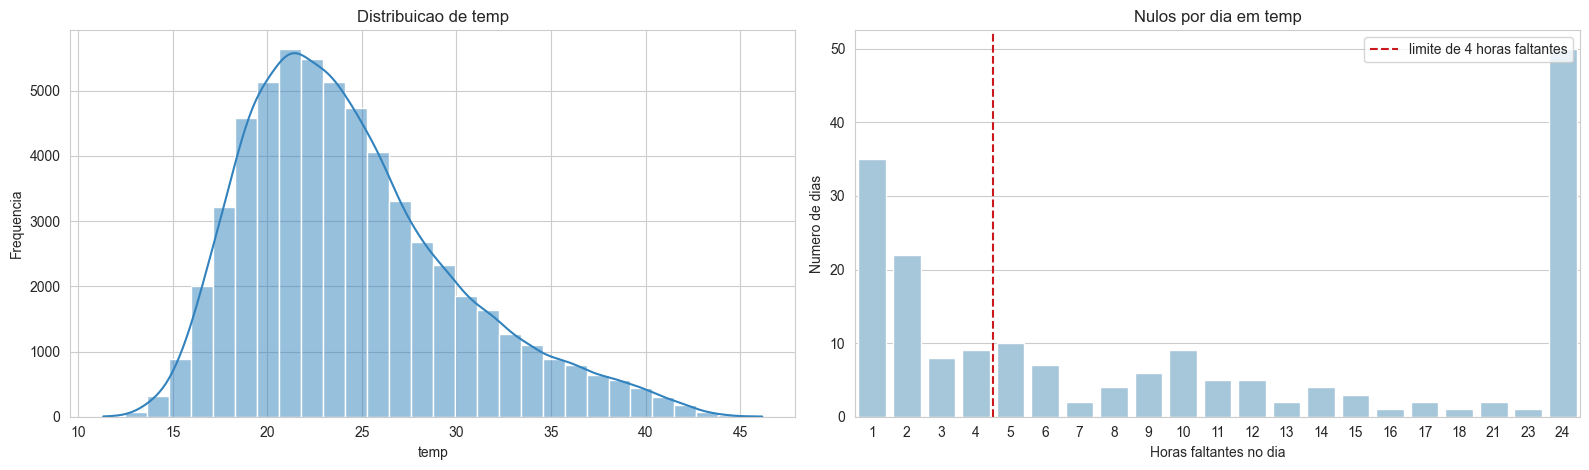

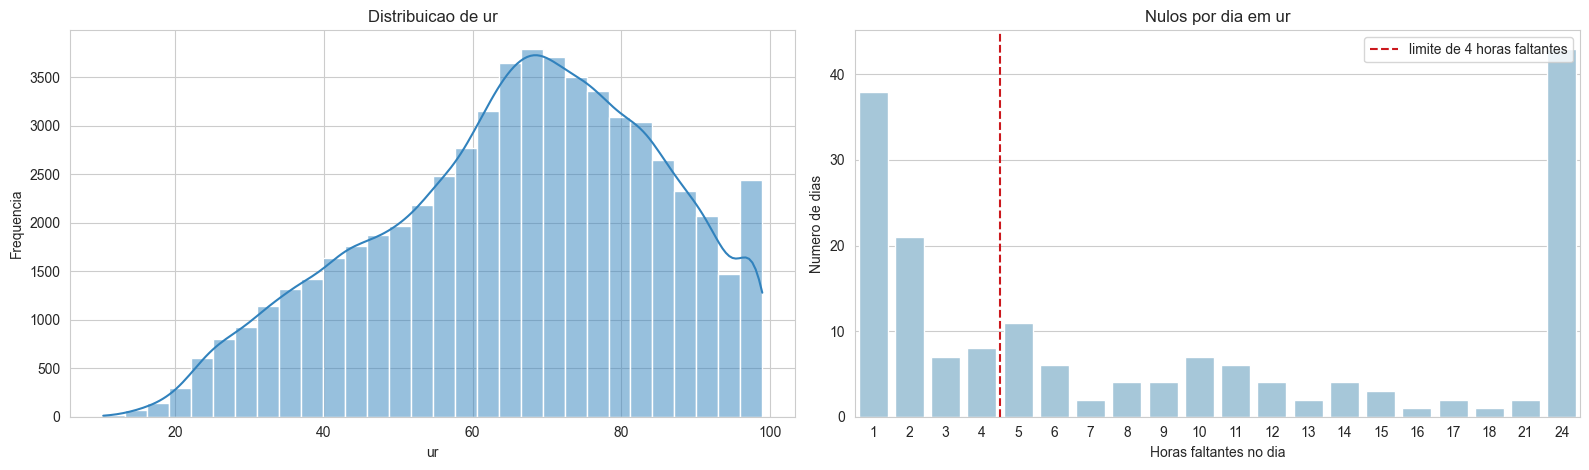

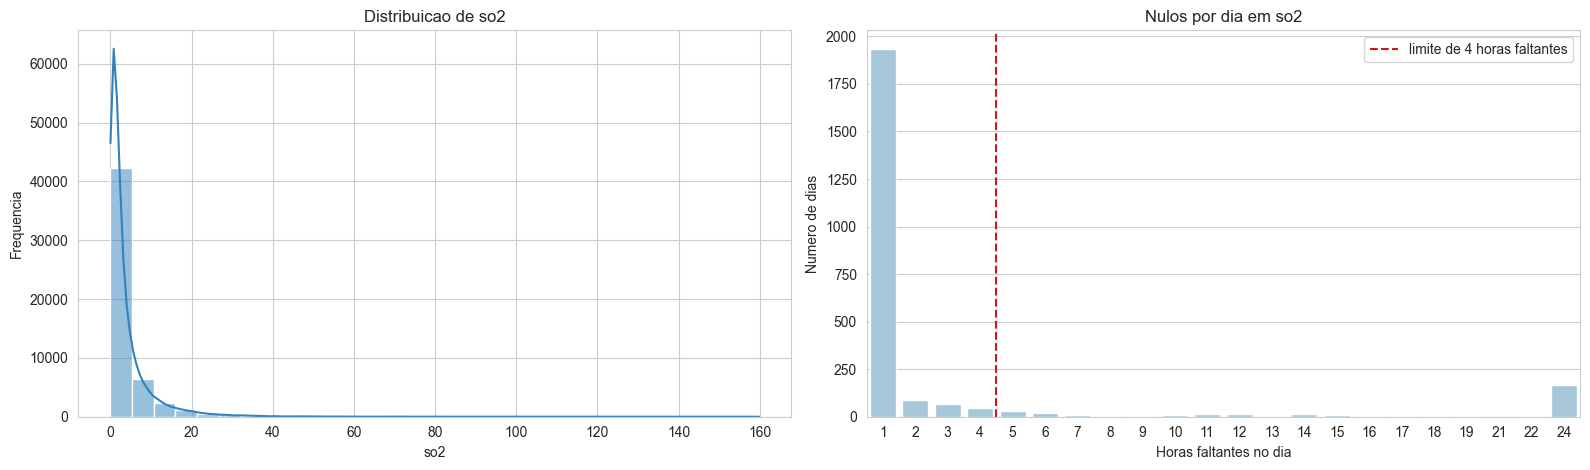

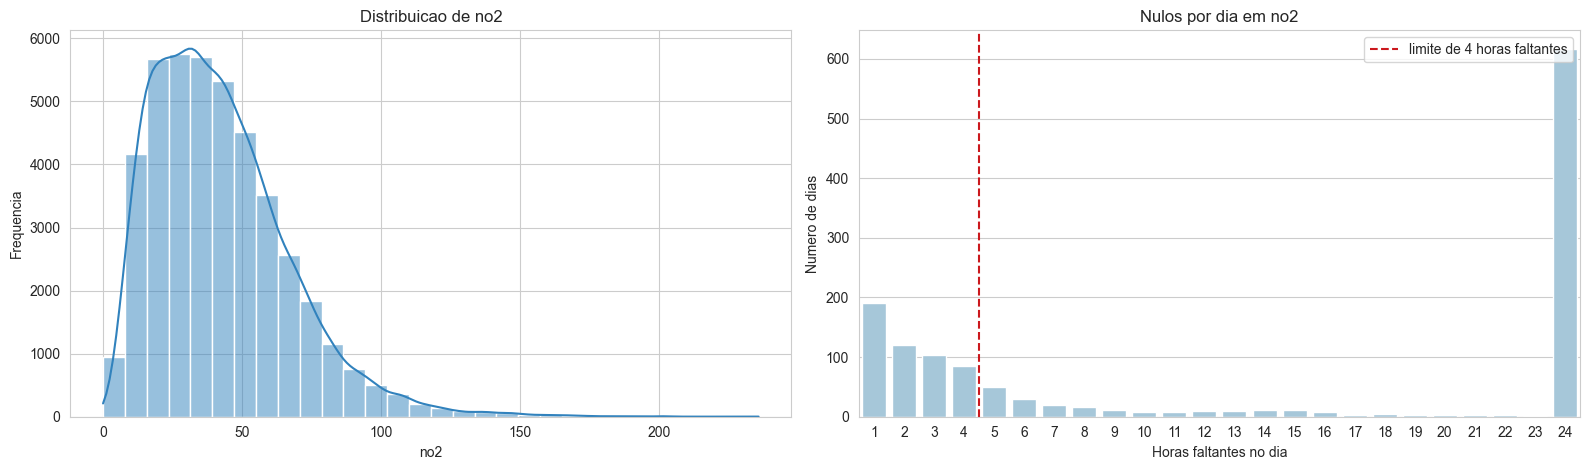

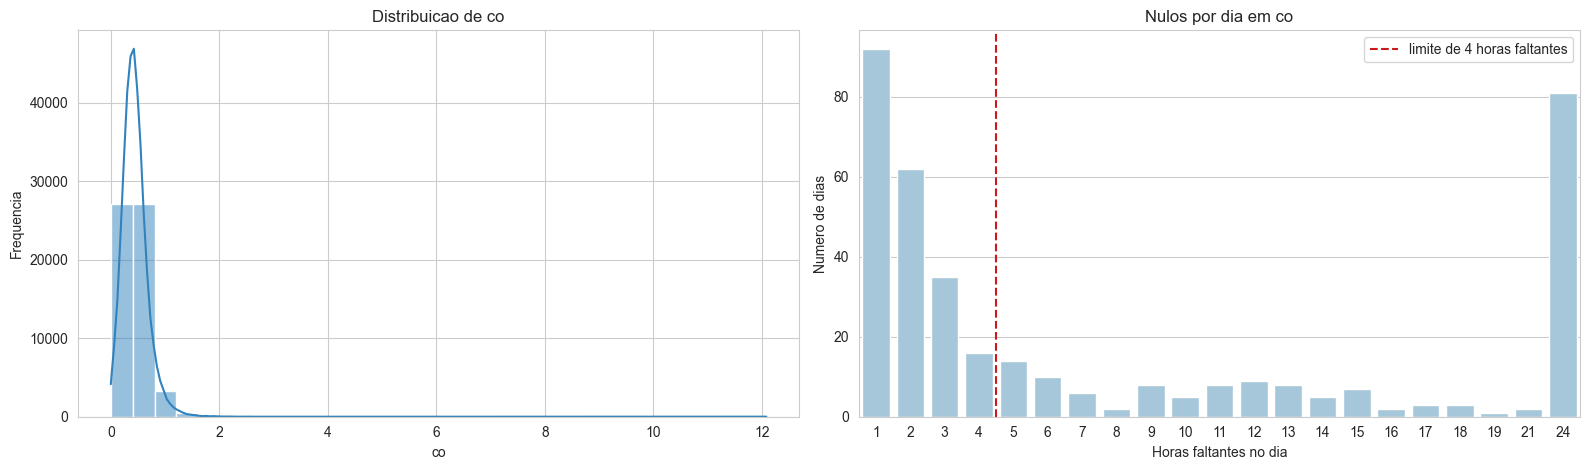

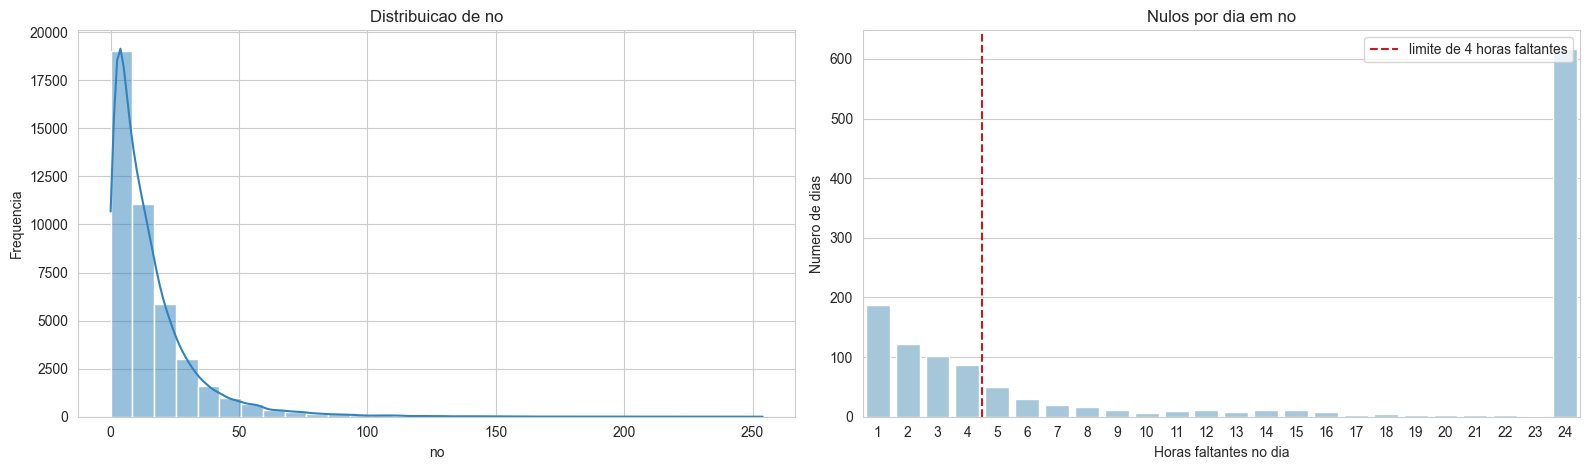

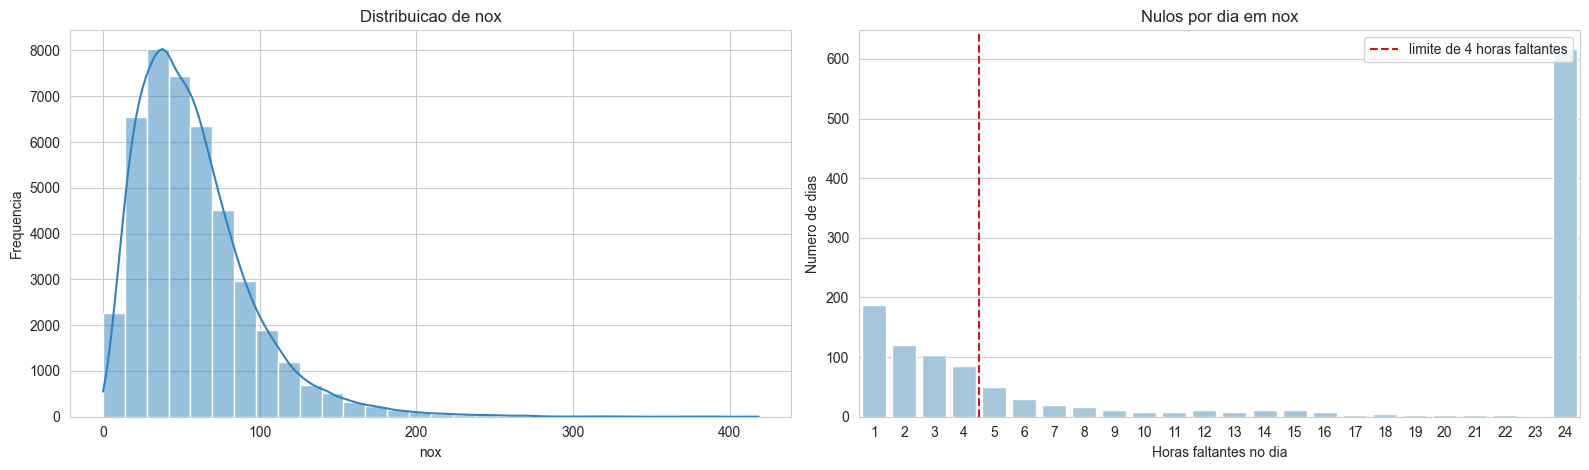

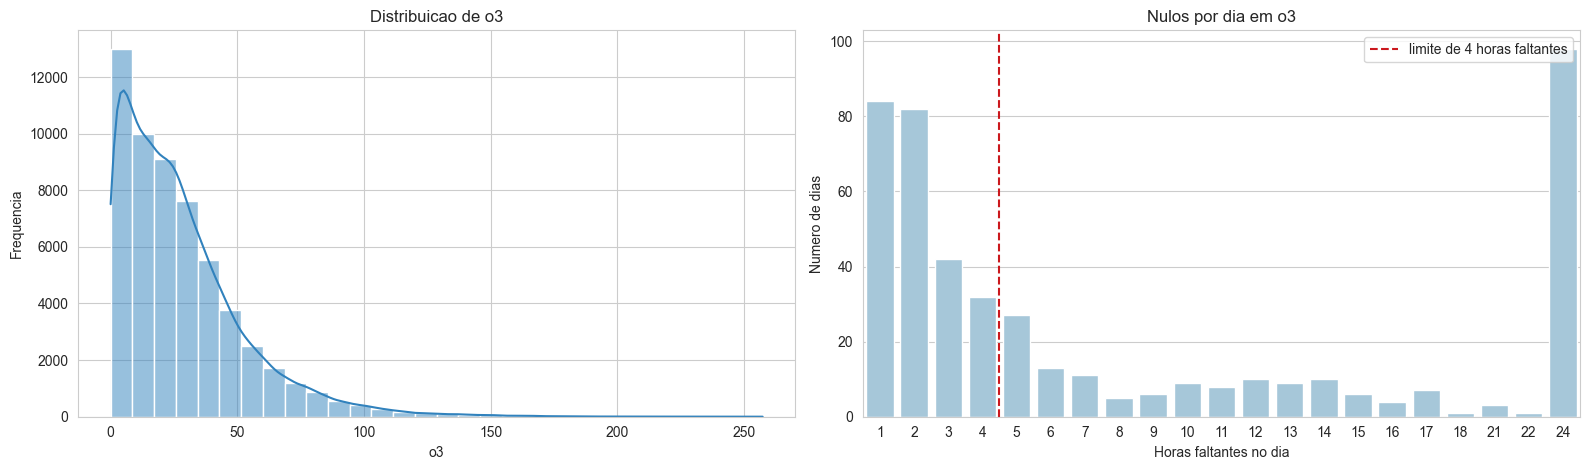

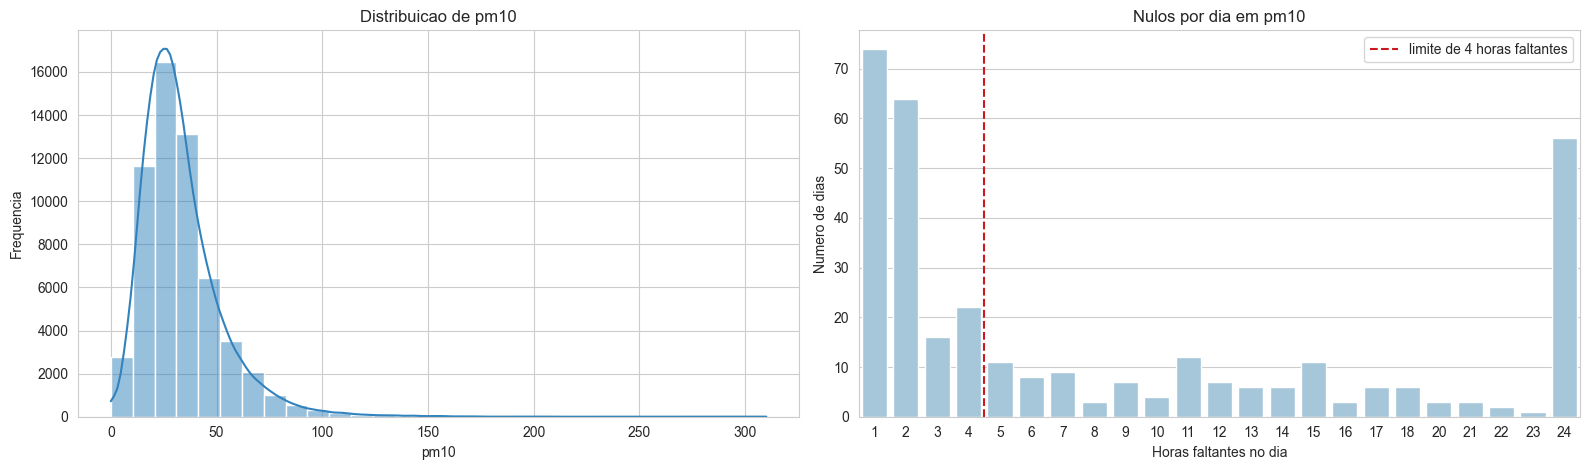

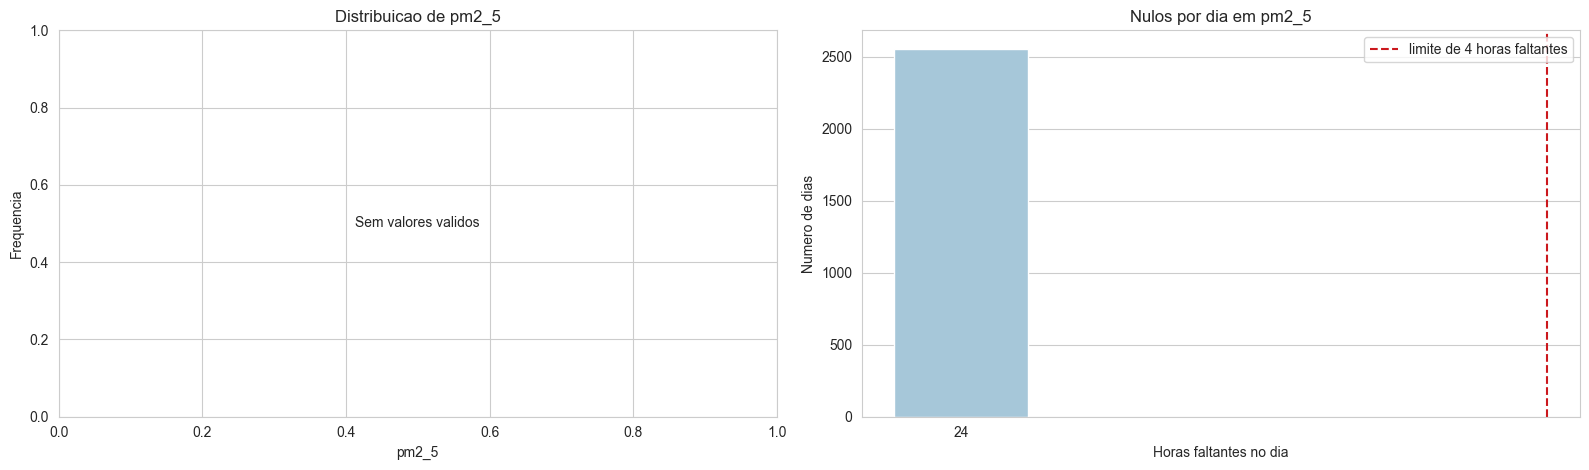

In [9]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_tijuca_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a estação da Tijuca tem uma base **muito boa do ponto de vista temporal e operacional**, com cobertura contínua de `2012-01-01 00:30` a `2018-12-31 23:30`, frequência horária regular, ausência de timestamps faltantes, ausência de duplicatas de horário e nenhuma evidência de mudança de nome ou coordenadas. Isso sugere que, para esta estação, a estrutura temporal da série está íntegra e o principal cuidado analítico passa a ser a completude desigual entre as variáveis monitoradas, e não a linha do tempo da base.

A leitura de missing por variável mostra uma separação clara de qualidade. `pm2_5` está estruturalmente indisponível (`100%` de nulos) e, neste recorte, não deve ser tratado como série analisável. Além disso, `no`, `no2` e `nox` apresentam perdas altas, em torno de `29,2%`, o que limita análises contínuas dessas séries sem algum tratamento prévio. `so2` (`13,0%`) também exige cautela adicional. Em contraste, `chuva` (`2,5%`), `ur` (`2,9%`), `temp` (`3,3%`), `pm10` (`4,8%`), `co` (`5,4%`) e `o3` (`6,8%`) aparecem em condição mais favorável. Isso faz da Tijuca uma estação com boa diversidade de variáveis úteis, mas com assimetria importante de qualidade entre poluentes.

As distribuições reforçam que a estação monitora processos heterogêneos com sinal urbano bastante marcado. Entre as variáveis meteorológicas, `chuva` segue fortemente concentrada em zero e muito assimétrica, enquanto `temp` e `ur` apresentam comportamento mais estável. Entre os poluentes, todas as séries disponíveis mostram **assimetria à direita**, indicando predominância de valores usuais com alguns episódios elevados; esse padrão é especialmente forte em `co`, `so2`, `pm2_5`, `pm10` e `o3`. Em Tijuca, chama atenção o nível central alto de `no2` (`42,4` de média), `nox` (`57,7`) e `co` (`0,45`), além de picos expressivos em `o3`, `pm10`, `so2` e `nox`. Isso sugere uma estação particularmente útil para estudar dinâmica de tráfego, mistura de poluentes primários e secundários e eventos intensos de material particulado.

A distribuição diária de nulos também ajuda a separar o que é lacuna curta do que é perda mais severa. `so2` chama atenção por um comportamento muito específico: poucos dias totalmente completos, mas uma concentração enorme de dias com apenas `1` a `4` horas faltantes, o que o torna um candidato forte para preenchimento pontual. `co`, `pm10`, `o3`, `temp`, `ur` e `chuva` também preservam muitos dias completos e parte relevante das falhas remanescentes está em lacunas curtas, o que favorece imputação local em parte da série. Já `no`, `no2` e `nox` combinam perda total alta com muitos dias severamente incompletos, exigindo bem mais cautela. `pm2_5`, por sua vez, não apresenta um problema de lacuna curta: a série está estruturalmente ausente.

Em síntese, a estação da Tijuca parece **forte como plataforma de monitoramento** no nível da base, porque combina cobertura temporal íntegra com um conjunto amplo de poluentes disponíveis. O principal cuidado analítico passa a ser tratar cada variável conforme sua qualidade: `pm2_5` deve ser excluído ou marcado como indisponível, `no`, `no2` e `nox` exigem maior controle de completude, e `chuva`, `temp`, `ur`, `co`, `o3`, `pm10` e `so2` podem seguir com boa utilidade para as próximas etapas da EDA, especialmente quando houver estratégia clara para imputar lacunas curtas. Isso deixa claro que, na Tijuca, a confiabilidade é alta no nível da base e boa no potencial analítico, mas com limitações importantes em parte das variáveis nitrogenadas.
